In [1]:
import pandas as pd

In [2]:
from nsepy import get_history as gh
import datetime as dt

In [3]:
import yfinance as yf
import pandas as pd
import datetime as dt

start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("TATACONSUM.NS", start=start, end=end)

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker     TATACONSUM.NS TATACONSUM.NS TATACONSUM.NS TATACONSUM.NS   
Date                                                                 
2021-07-01    725.378296    729.168063    719.573746    725.138438   
2021-07-02    732.622070    737.611127    722.644015    727.153356   
2021-07-05    735.212524    740.201581    733.965275    739.194190   
2021-07-06    731.662598    737.802984    727.249235    736.843552   
2021-07-07    732.094360    734.972656    720.773078    728.208674   

Price             Volume  
Ticker     TATACONSUM.NS  
Date                      
2021-07-01       1914434  
2021-07-02       1916135  
2021-07-05       1020895  
2021-07-06       1411602  
2021-07-07       2104914  


In [4]:
column="Close"

In [5]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (144, 1)


In [6]:
training_size = round(len(data1 ) * 0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

137
X_train length: (137, 1)
X_test length: (7, 1)
y_train length: (137, 1)
y_test length: (7, 1)


In [7]:
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

trends = ['n','t','c','ct']

for td in trends:

    model = ARIMA(X_train, order=(0,0,2), trend=td)   # MA model
    model_fit = model.fit()

    # prediction
    y_pred = model_fit.predict(len(X_train), len(data1)-1)

    mse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("Trend={}".format(td))
    print("RMSE:", mse)
    print("****")

Trend=n
RMSE: 0.11653785581515413
****
Trend=t
RMSE: 0.6073175287183702
****
Trend=c
RMSE: 0.41510252512475454
****


/Users/siva/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/siva/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/siva/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/siva/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=ct
RMSE: 0.30145077381363566
****


In [8]:
print(y_test)

[[0.20980797]
 [0.13742422]
 [0.16784645]
 [0.18410665]
 [0.        ]
 [0.08549669]
 [0.07605523]]


In [9]:
len(y_pred)

7

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", mse)

RMSE: 0.30145077381363566


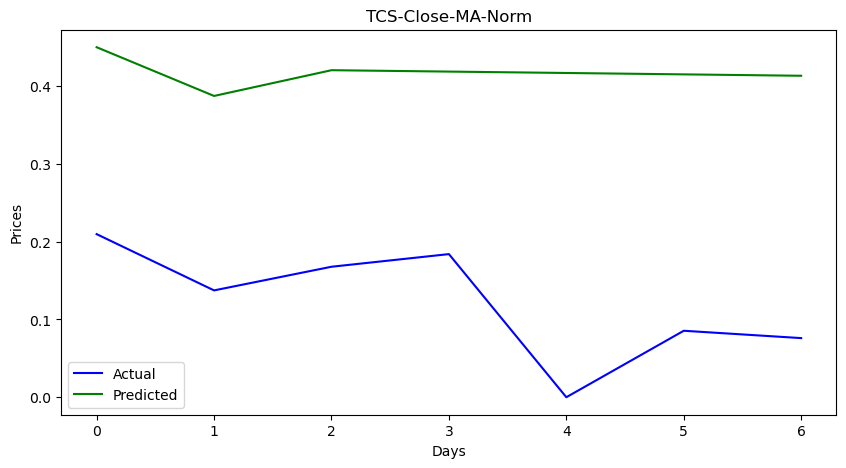

In [11]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TCS-Close-MA-Norm","Days","Prices")

In [12]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [13]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

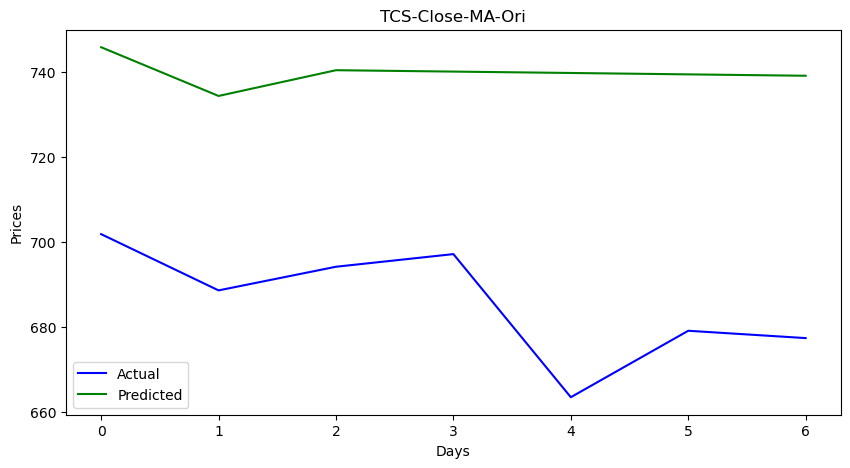

In [14]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TCS-Close-MA-Ori","Days","Prices")

In [15]:
def rmsemape(y_Test,predicted_stock_price_test_ori):
    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    print("RMSE-Testset:", np.sqrt(mean_squared_error(y_Test, predicted_stock_price_test_ori)))

    from sklearn.metrics import mean_absolute_percentage_error
    print("MAPE-Testset:", mean_absolute_percentage_error(y_Test, predicted_stock_price_test_ori))

In [16]:
forecast=model_fit.predict(len(data1), len(data1))

In [17]:
forecast

array([0.4117478])

In [18]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [19]:
forecast_stock_price_test_oriF

,Closefore
0,738.714236
